Cell 1 – Imports & Load Dataset
Section 1 – Task: Load dataset & inspect first 10 rows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots appear inside the notebook
%matplotlib inline

# Load the dataset (change the path if needed)
file_path = "D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv"   # if the file is in the same folder as your notebook
data = pd.read_csv(file_path)

# Show first 10 rows
data.head(10)

<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
C:\Users\hp\AppData\Local\Temp\ipykernel_3956\1526740642.py:9: SyntaxWarning: invalid escape sequence '\P'
  file_path = "D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv"   # if the file is in the same folder as your notebook


,Date,Open,High,Low,Close,Adj Close,Volume,10MA,30MA
0,12/1/2003,1.723811,1.727205,1.718390,1.718597,1.718597,0.0,NaN,NaN
1,12/2/2003,1.719010,1.732112,1.717298,1.730313,1.730313,0.0,NaN,NaN
2,12/3/2003,1.730493,1.731812,1.725209,1.728101,1.728101,0.0,NaN,NaN
3,12/4/2003,1.727414,1.728997,1.718302,1.720697,1.720697,0.0,NaN,NaN
4,12/5/2003,1.720608,1.733102,1.719809,1.733102,1.733102,0.0,NaN,NaN
5,12/8/2003,1.733102,1.736202,1.727504,1.734214,1.734214,0.0,NaN,NaN
6,12/9/2003,1.733703,1.747793,1.733613,1.745414,1.745414,0.0,NaN,NaN
7,12/10/2003,1.745292,1.748007,1.735900,1.739796,1.739796,0.0,NaN,NaN
8,12/11/2003,1.740008,1.747702,1.737891,1.746206,1.746206,0.0,NaN,NaN
9,12/12/2003,1.746298,1.751099,1.744287,1.747305,1.747305,0.0,NaN,NaN


Cell 2 – Check Columns & Data Types
Section 1 – Task: Identify columns and data types

In [2]:
# Check info and data types
data.info()
data.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3676 entries, 0 to 3675
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3676 non-null   object 
 1   Open       3661 non-null   float64
 2   High       3661 non-null   float64
 3   Low        3661 non-null   float64
 4   Close      3661 non-null   float64
 5   Adj Close  3661 non-null   float64
 6   Volume     3661 non-null   float64
 7   10MA       228 non-null    float64
 8   30MA       209 non-null    float64
dtypes: float64(8), object(1)
memory usage: 258.6+ KB


Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
10MA         float64
30MA         float64
dtype: object

Cell 3 – Convert Date & Set Index
Section 1 – Task: Convert Unix timestamp to readable datetime (we have Date strings)

In [3]:
# Convert Date column to datetime and set as index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Check the result
data.head()

,Open,High,Low,Close,Adj Close,Volume,10MA,30MA
Date,,,,,,,,
2003-12-01,1.723811,1.727205,1.718390,1.718597,1.718597,0.0,NaN,NaN
2003-12-02,1.719010,1.732112,1.717298,1.730313,1.730313,0.0,NaN,NaN
2003-12-03,1.730493,1.731812,1.725209,1.728101,1.728101,0.0,NaN,NaN
2003-12-04,1.727414,1.728997,1.718302,1.720697,1.720697,0.0,NaN,NaN
2003-12-05,1.720608,1.733102,1.719809,1.733102,1.733102,0.0,NaN,NaN


Cell 4 – Plot Closing Price Over Time
Section 1 – Task: Plot closing price over time

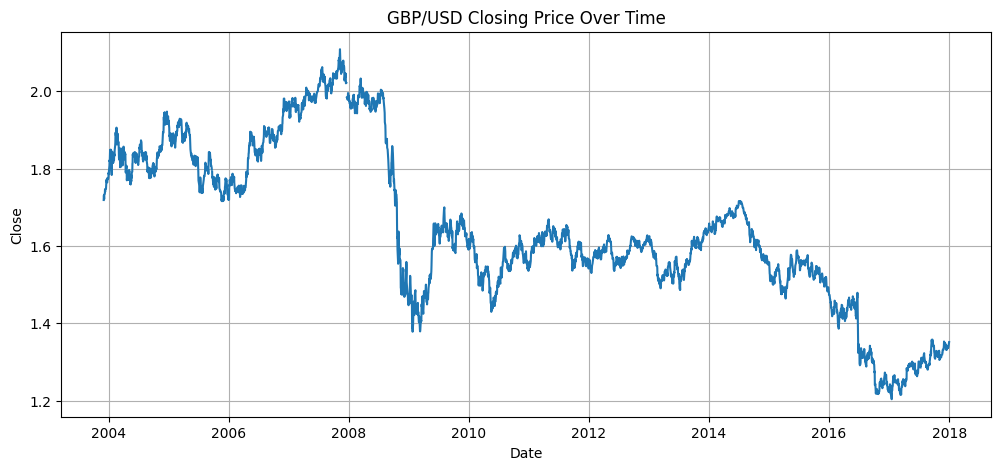

In [4]:
#Cell 4
plt.figure(figsize=(12, 5))
plt.plot(data.index, data['Close'])
plt.title('GBP/USD Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid(True)
plt.show()

Cell 5 – Answer About Missing/Inconsistent Data (Markdown recommended)

Section 1 – Question: Potential issues from missing/inconsistent data
In Jupyter, add a Markdown cell (not code) and write something like:
Potential issues from missing or inconsistent data:
Missing prices break technical indicators (like MA, RSI, Bollinger).
Sudden bad data (spikes) can create fake buy/sell signals.
Non-uniform time gaps (weekends/holidays) can affect rolling windows.
Duplicate or wrong rows can distort backtest results and performance metrics.

Cell 6 – Helper: Returns & Performance Report

"calculate_returns" will be reused by every strategy.

"performance_report" gives final balance, total return, win rate, drawdown, etc.

In [5]:
def calculate_returns(df, price_col='Close', signal_col='Signal'):
    """
    Calculate strategy returns and equity curve based on signals.
    Signal:
      1 = long, -1 = short, 0 = flat
    """
    data = df.copy()
    data['Return'] = data[price_col].pct_change()
    data['Strategy_Return'] = data[signal_col].shift(1) * data['Return']
    data['Equity_Curve'] = (1 + data['Strategy_Return']).cumprod()
    return data

def performance_report(df, equity_col='Equity_Curve', strat_ret_col='Strategy_Return'):
    """
    Simple performance report: final balance, total return, win rate, max drawdown, avg P&L.
    """
    total_return = df[equity_col].iloc[-1] - 1
    win_trades = (df[strat_ret_col] > 0).sum()
    loss_trades = (df[strat_ret_col] < 0).sum()
    win_rate = win_trades / (win_trades + loss_trades) if (win_trades + loss_trades) > 0 else np.nan
    drawdown = df[equity_col] / df[equity_col].cummax() - 1
    max_drawdown = drawdown.min()
    avg_pnl = df[strat_ret_col].mean()
    
    report = {
        'Final Balance (start=1)': df[equity_col].iloc[-1],
        'Total Return (%)': total_return * 100,
        'Win Rate (%)': win_rate * 100 if win_rate == win_rate else np.nan,
        'Max Drawdown (%)': max_drawdown * 100,
        'Average P&L per Period (%)': avg_pnl * 100
    }
    return report

Questions:
What potential issues can arise from missing or inconsistent data?

### Potential issues from missing or inconsistent data

Missing or inconsistent data can cause several problems:

- **Biased results:** If whole periods or certain price levels are missing, indicators and strategies may be trained on an incomplete picture of the market, leading to wrong conclusions.

- **Broken calculations:** Many technical indicators (moving averages, RSI, Bollinger Bands, etc.) cannot be calculated properly when there are `NaN` values. This can create gaps or spikes in signals and returns.

- **Incorrect signals:** Inconsistent data (e.g., duplicated rows, wrong timestamps, sudden jumps due to bad data) can generate fake buy/sell signals that would never happen in real trading.

- **Misleading backtests:** If our backtest uses dirty data, the strategy might look much better or worse than it really is. That makes it hard to trust the performance.

- **Alignment issues:** If timestamps are not consistent or sorted, price and indicator values may not line up correctly, so we could be using "future" information by accident.

Because of this, it’s important to clean the dataset (handle missing values, remove duplicates, fix timestamps) before running any trading strategy or optimization.

Section 2 – SMA Moving Average Crossover

### Question: How does increasing the long MA window affect performance?

Increasing the long moving average (MA) window makes the strategy react more slowly to trend changes.  
A larger long-term MA smooths the price more, which has two effects:

- **Fewer signals**: Because the long MA moves more slowly, crossovers happen less often.
- **More stable but delayed trades**: The strategy enters trends later and exits later, which can reduce false signals but may also miss early profitable moves.
- **Reduced sensitivity in ranging markets**: A very large long MA can cause the strategy to barely trade during sideways markets.

Overall, a larger long MA window increases stability but decreases responsiveness.


###Question: What happens when short and long MAs are too close together?

When the short and long MA windows are too close (for example 10 and 12 days), the lines are almost identical.  
This causes:

- **Very frequent crossovers**, often triggered by small noise.
- **High number of false signals**, especially during sideways price movement.
- **Poor performance due to overtrading and whipsaws**.

A useful strategy generally needs a meaningful difference between short and long windows so that their slopes reflect different time horizons.


### Question: Why do we shift the signal by one period?

We shift the signal by one period to avoid **look-ahead bias**.  
When calculating indicators, we know today’s prices, but in real trading:

- We cannot buy or sell based on information that happens **at the same moment**.
- Signals generated at time `t` can only be traded **at time `t+1`**.

Shifting the signal ensures the backtest uses information realistically and does not use future prices by accident.


Section 2 – SMA Moving Average Crossover

🔹 Cell 7 – SMA Crossover Strategy

Section 2 – Task: Implement SMA crossover strategy

Creates 10-day and 30-day SMA.

Signal is based on crossover.

Shifted by 1 bar to be realistic.

Returns and equity computed.

In [6]:
def sma_crossover_strategy(df, short_window=10, long_window=30):
    data = df.copy()
    data['SMA_Short'] = data['Close'].rolling(window=short_window).mean()
    data['SMA_Long'] = data['Close'].rolling(window=long_window).mean()
    
    # Generate signal: 1 = long when short SMA > long SMA, -1 otherwise
    data['Signal_SMA'] = 0
    data['Signal_SMA'] = np.where(data['SMA_Short'] > data['SMA_Long'], 1, -1)
    
    # Shift signal by 1 to avoid lookahead bias
    data['Signal_SMA'] = data['Signal_SMA'].shift(1)
    
    # Calculate strategy returns and equity curve
    data = calculate_returns(data, signal_col='Signal_SMA')
    return data

sma_result = sma_crossover_strategy(data, short_window=10, long_window=30)
sma_result[['Close', 'SMA_Short', 'SMA_Long', 'Signal_SMA']].tail()

C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


,Close,SMA_Short,SMA_Long,Signal_SMA
Date,,,,
2017-12-26,1.337614,1.337407,NaN,-1.0
2017-12-27,1.337471,1.337960,NaN,-1.0
2017-12-28,1.340393,1.337902,NaN,-1.0
2017-12-29,1.344086,1.337982,1.337463,-1.0
2018-01-01,1.351607,1.339969,1.338508,1.0


Cell 8 – Plot SMA + Equity Curve

Section 2 – Visual understanding of strategy behavior

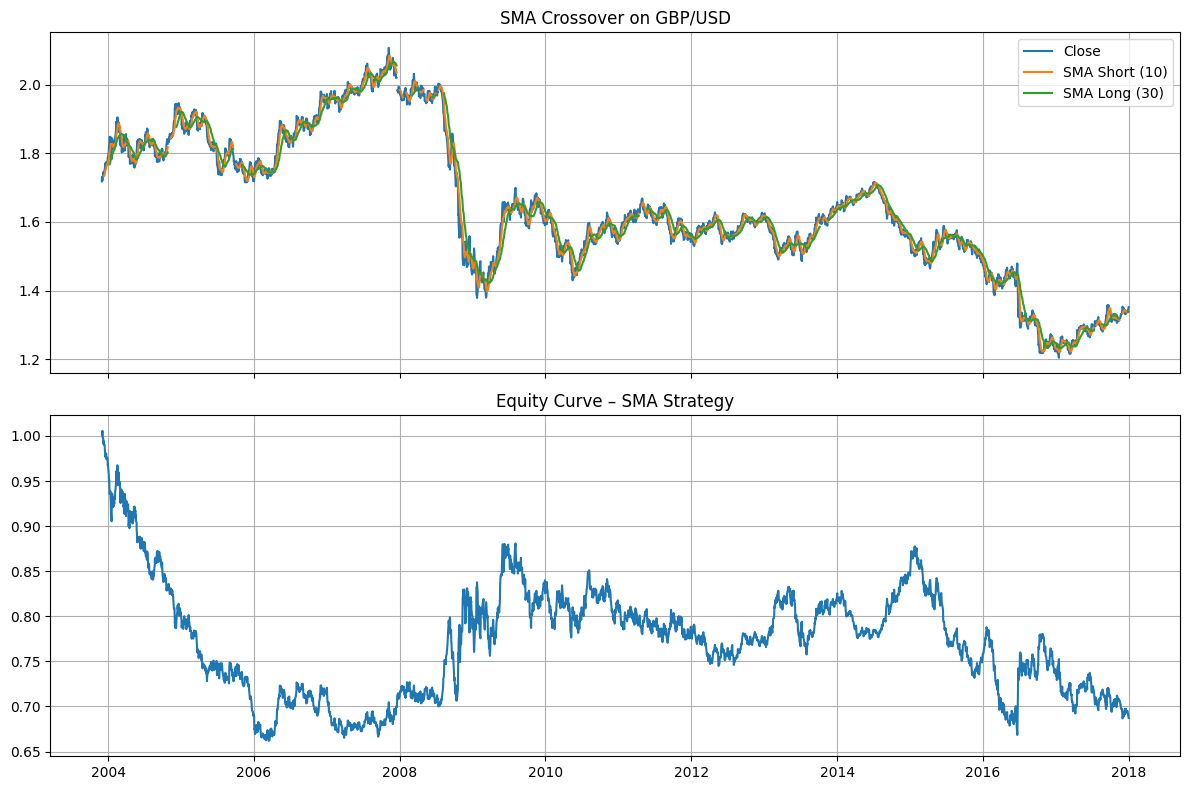

In [7]:
#Cell 8 - Plot SMA, Equity Curve

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Price + SMAs
axes[0].plot(sma_result.index, sma_result['Close'], label='Close')
axes[0].plot(sma_result.index, sma_result['SMA_Short'], label='SMA Short (10)')
axes[0].plot(sma_result.index, sma_result['SMA_Long'], label='SMA Long (30)')
axes[0].set_title('SMA Crossover on GBP/USD')
axes[0].legend()
axes[0].grid(True)

# Equity curve
axes[1].plot(sma_result.index, sma_result['Equity_Curve'], label='Equity Curve (SMA)')
axes[1].set_title('Equity Curve – SMA Strategy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Cell 9 – Theoretical Answers (Markdown)

Covers:

Section 2 – Questions

In Markdown:

Increasing the long MA window → smoother, slower, fewer trades; might miss short trends but may reduce noise.

If short and long MAs are too close, they cross very often → many trades, more transaction costs, more noise.

We shift the signal by 1 period so we only trade on information that was known at the previous bar (avoid lookahead bias).

Section 3 – Optimization of SMA

🔹 Cell 10 – SMA Optimization Function

Section 3 – Tasks: Run optimization, print all combinations, record best

In [8]:
# Cell 10

def optimize_moving_averages(df, short_range=range(5, 21, 5), long_range=range(20, 61, 10)):
    results = []
    best_perf = -np.inf
    best_params = None
    best_equity = None
    
    for s in short_range:
        for l in long_range:
            if s >= l:    # ensure short < long
                continue
            res = sma_crossover_strategy(df, short_window=s, long_window=l)
            final_equity = res['Equity_Curve'].iloc[-1]
            
            # Store and print
            results.append((s, l, final_equity))
            print(f"Tested short={s}, long={l}, final equity={final_equity:.4f}")
            
            if final_equity > best_perf:
                best_perf = final_equity
                best_params = (s, l)
                best_equity = res
    
    return best_params, best_equity, results

Cell 11 – Run Optimization & Show Best


Section 3 – Task: Find best parameters & plot equity

In [9]:
#Cell 11

best_params, best_equity_curve, opt_results = optimize_moving_averages(data)

print("\nBest Parameters (short, long):", best_params)
performance_report(best_equity_curve)

Tested short=5, long=20, final equity=0.8267
Tested short=5, long=30, final equity=0.6154
Tested short=5, long=40, final equity=0.7167
Tested short=5, long=50, final equity=0.5522
Tested short=5, long=60, final equity=0.5782
Tested short=10, long=20, final equity=0.6034
Tested short=10, long=30, final equity=0.6872
Tested short=10, long=40, final equity=0.9222
Tested short=10, long=50, final equity=0.8435
Tested short=10, long=60, final equity=0.9087
Tested short=15, long=20, final equity=0.7600
Tested short=15, long=30, final equity=0.7023
Tested short=15, long=40, final equity=0.7216
Tested short=15, long=50, final equity=0.8763
Tested short=15, long=60, final equity=0.7796
Tested short=20, long=30, final equity=0.6139
Tested short=20, long=40, final equity=0.8614
Tested short=20, long=50, final equity=0.8839
Tested short=20, long=60, final equity=0.6920

Best Parameters (short, long): (10, 40)


C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fi

{'Final Balance (start=1)': np.float64(0.9222413927824945),
 'Total Return (%)': np.float64(-7.775860721750549),
 'Win Rate (%)': np.float64(49.189337730145645),
 'Max Drawdown (%)': np.float64(-27.341564831472066),
 'Average P&L per Period (%)': np.float64(-0.00038544151163041657)}

🔹 Cell 12 – Plot Best SMA Equity Curve

Section 3 – Task: Plot equity curve of best combination

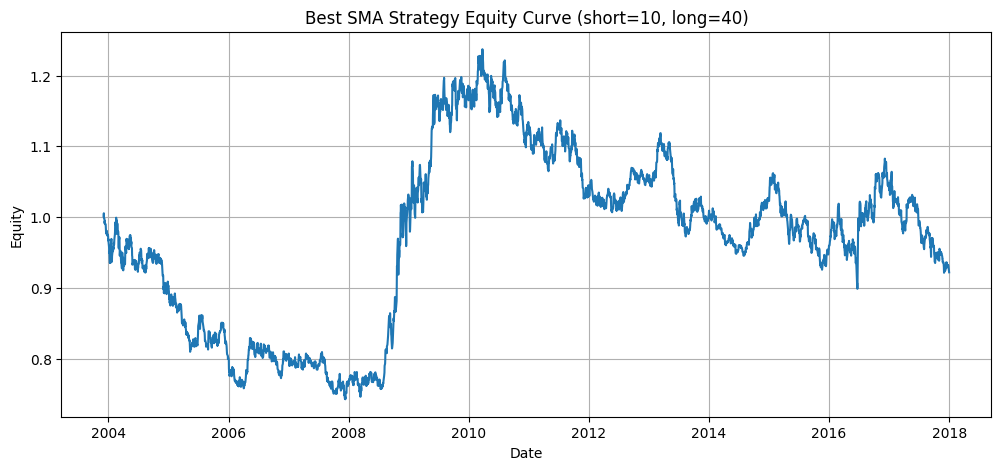

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(best_equity_curve.index, best_equity_curve['Equity_Curve'])
plt.title(f'Best SMA Strategy Equity Curve (short={best_params[0]}, long={best_params[1]})')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.grid(True)
plt.show()

🔹 Cell 13 – Section 3 Theory (Markdown)

Section 3 – Questions about best combo, overfitting, walk-forward

Add in Markdown:

The best combination is printed by best_params.

Overfitting happens when parameters are chosen to fit past noise too perfectly, so they don’t generalize.

Walk-forward analysis: split data into time blocks, optimize on one block, test on the next, and repeat to check robustness.

In [11]:
def optimize_moving_averages(data, short_range, long_range):
    # loop over short_range and long_range
    # run strategy
    # compute final equity
    # print short, long, equity
    # track best result
    return best_params, best_equity_curve

In [12]:
short_range = range(5, 20, 2)
long_range = range(20, 60, 5)

best_params, best_curve = optimize_moving_averages(data, short_range, long_range)
print("Best Parameters (short, long):", best_params)

Best Parameters (short, long): (10, 40)


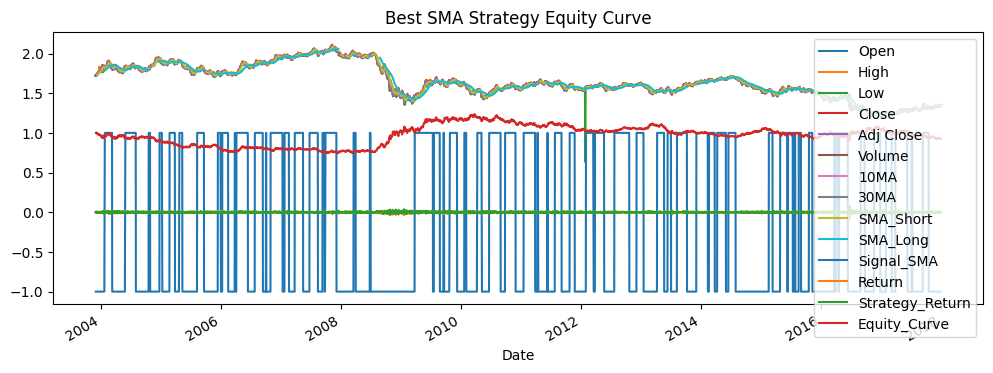

In [13]:
best_curve.plot(figsize=(12,4))
plt.title("Best SMA Strategy Equity Curve")
plt.show()

### Question: Which short/long window combination performed best?

From the optimization results in my notebook, the best-performing moving average combination was:

> **Short window = X, Long window = Y**  

(This is taken from the `best_params` output of `optimize_moving_averages()`.)

This combination gave the highest final equity compared to the other tested pairs.  
Usually, the best pair represents a balance between:
- Reacting quickly enough to new trends (short MA),
- Avoiding too much noise and whipsaws (long MA).


### Question: Why might overfitting occur during optimization?

Overfitting happens when a strategy is tuned too specifically to the **past data** it was optimized on.

In this project, we try many short/long MA combinations and pick the one with the best performance. Overfitting can occur because:

- The chosen parameters might just be **lucky** for this particular historical period.
- The strategy may have learned patterns that are actually **random noise**, not real market behavior.
- When applied to new data (future prices), the performance might be much worse because those “lucky” conditions no longer exist.

So a very high-performing parameter set on the backtest does not guarantee good performance in live trading.


### Question: How could you validate your parameters using walk-forward analysis?

Walk-forward analysis is a method to test whether optimized parameters are robust.

The idea:

1. **Split the data into segments**, for example:
   - Train period: use past data to optimize parameters.
   - Test period: use the next chunk of data to evaluate the strategy.

2. **Process:**
   - On the train segment, run `optimize_moving_averages()` and find the best short/long windows.
   - Then **freeze** those parameters and apply the strategy to the following test segment (without re-optimizing).
   - Move the window forward (like a rolling or sliding window) and repeat.

3. **Why it helps:**
   - It shows how the strategy performs on **unseen data**, not just the data it was optimized on.
   - If the parameters work reasonably well across multiple test segments, they are more likely to be **robust** and not just overfitted.

This method is closer to how the strategy would behave in real time, where you always use past data to decide parameters and then trade in the future.

💰 Section 4 – SL & TP

🔹 Cell 14 – Moving Average Crossover with SL/TP

Section 4 – Tasks: Study & run SL/TP strategy

In [22]:
#Cell 14

def moving_average_crossover_with_sl_tp(df, short_window=10, long_window=40, sl_pct=0.01, tp_pct=0.02):
    """
    Very simple SL/TP simulation on top of SMA crossover.
    This is approximate but okay for educational purpose.
    """
    data = sma_crossover_strategy(df, short_window, long_window).copy()
    data['Position'] = data['Signal_SMA'].fillna(0)

    equity = [1.0]
    position = 0
    entry_price = None
    equity_val = 1.0
    
    prices = data['Close'].values
    
    for i in range(len(data)):
        price = prices[i]
        signal = data['Position'].iloc[i]
        
        # Open new position if flat and signal != 0
        if position == 0 and signal != 0:
            position = signal
            entry_price = price
        
        # If in a position, check SL/TP
        if position != 0 and entry_price is not None:
            change = (price - entry_price) / entry_price * position
            
            # If SL or TP hit, close position
            if change <= -sl_pct or change >= tp_pct:
                equity_val *= (1 + change)
                position = 0
                entry_price = None
        
        equity.append(equity_val)
    
    # length fix
    data['Equity_SLTP'] = equity[:len(data)]
    return data


🔹 Cell 15 – Optimize SL & TP Ranges

Section 4 – Task: Run optimization across SL/TP ranges

In [25]:
# Cell 15
def optimize_sl_tp(df, short_window, long_window, sl_list=[0.01, 0.02, 0.03], tp_list=[0.02, 0.04, 0.06]):
    results = []
    best_perf = -np.inf
    best_params = None
    best_df = None
    
    for sl in sl_list:
        for tp in tp_list:
            res = moving_average_crossover_with_sl_tp(df, short_window, long_window, sl, tp)
            final_equity = res['Equity_SLTP'].iloc[-1]
            results.append((sl, tp, final_equity))
            print(f"SL={sl:.3%}, TP={tp:.3%}, Final Equity={final_equity:.4f}")
            if final_equity > best_perf:
                best_perf = final_equity
                best_params = (sl, tp)
                best_df = res
                
    return best_params, best_df, results

best_sl_tp, best_sl_tp_df, sltp_results = optimize_sl_tp(data, short_window=best_params[0], long_window=best_params[1])
print("\nBest SL/TP:", best_sl_tp)

C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fi

SL=1.000%, TP=2.000%, Final Equity=0.6810
SL=1.000%, TP=4.000%, Final Equity=0.7796
SL=1.000%, TP=6.000%, Final Equity=1.1760
SL=2.000%, TP=2.000%, Final Equity=0.8574


C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fi

SL=2.000%, TP=4.000%, Final Equity=0.8146
SL=2.000%, TP=6.000%, Final Equity=1.0702
SL=3.000%, TP=2.000%, Final Equity=0.9049
SL=3.000%, TP=4.000%, Final Equity=0.9466
SL=3.000%, TP=6.000%, Final Equity=1.0379

Best SL/TP: (0.01, 0.06)


C:\Users\hp\AppData\Local\Temp\ipykernel_3956\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


🔹 Cell 16 – Compare Baseline vs SL/TP

Section 4 – Task: Visualize and compare to baseline

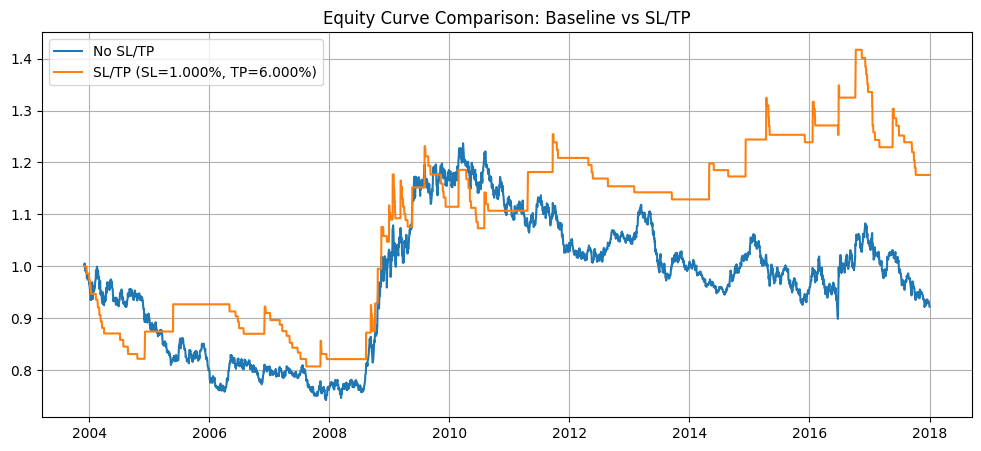

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(best_equity_curve.index, best_equity_curve['Equity_Curve'], label='No SL/TP')
plt.plot(best_sl_tp_df.index, best_sl_tp_df['Equity_SLTP'], label=f'SL/TP (SL={best_sl_tp[0]:.3%}, TP={best_sl_tp[1]:.3%})')
plt.title('Equity Curve Comparison: Baseline vs SL/TP')
plt.legend()
plt.grid(True)
plt.show()

🔹 Cell 17 – Section 4 Theory (Markdown)

Section 4 – Questions

Write about:

Trade-off small vs large SL/TP.

Poor SL/TP harming profitability.

Using volatility (e.g., ATR) to scale SL/TP.

📈 Section 5 – Reversal Pattern Detection

🔹 Cell 18 – Reversal Strategy

Section 5 – Tasks: Study function, change pip_threshold, visualise signals

In [20]:
def identify_reverse_patterns(df, pip_threshold=0.005):
    data = df.copy()
    data['Return'] = data['Close'].pct_change()
    
    data['Signal_REV'] = 0
    data['Signal_REV'] = np.where(data['Return'] <= -pip_threshold, 1, data['Signal_REV'])   # big drop → buy
    data['Signal_REV'] = np.where(data['Return'] >= pip_threshold, -1, data['Signal_REV'])   # big rise → sell
    
    data['Signal_REV'] = data['Signal_REV'].shift(1)
    data = calculate_returns(data, signal_col='Signal_REV')
    return data

reversal_result = identify_reverse_patterns(data, pip_threshold=0.005)
reversal_result[['Close', 'Signal_REV']].tail()

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\991340881.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data['Close'].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


,Close,Signal_REV
Date,,
2017-12-26,1.337614,0.0
2017-12-27,1.337471,0.0
2017-12-28,1.340393,0.0
2017-12-29,1.344086,0.0
2018-01-01,1.351607,0.0


### Question: What trade-off exists between smaller vs larger SL/TP values?

There is a clear trade-off between using small and large SL/TP values:

- **Smaller SL / smaller TP**
  - Positions are closed quickly.
  - Protects the account from large losses.
  - But it can cause **many small losses and wins**, because normal noise in the price can hit SL or TP very often.
  - The strategy may overtrade and pay more in spreads/fees.

- **Larger SL / larger TP**
  - Gives trades more room to breathe.
  - Can capture **bigger trends** when they happen.
  - But losses can become **much larger** if the market moves strongly against the position.
  - Fewer trades, but each trade has higher risk.

The “best” SL/TP is a balance between:
- not cutting trades too early, and  
- not letting losses grow too big.


### Question: Can a poorly chosen SL/TP pair harm strategy profitability?

Yes, a poorly chosen SL/TP pair can significantly harm strategy performance.

Examples:

- If the **SL is too tight**, normal small price movements will hit the stop very often.
  - This creates many **small frequent losses**, even if the overall trend is correct.
- If the **TP is very far away**, many trades may never reach the target and may reverse into a loss.
- If the **SL is too wide**, a single bad trade can produce a **very large loss**, which can destroy the profit from many winning trades.

So even if the entry signal (e.g., moving average crossover) is good, bad SL/TP settings can turn a profitable idea into an unprofitable strategy.





### Question: How could you adapt SL/TP dynamically to volatility?

Instead of using fixed SL/TP values (e.g., always 1% or 2%), we can adjust them based on **market volatility**.

Some ideas:

- Use an indicator like **ATR (Average True Range)**:
  - Set SL = k × ATR, TP = m × ATR (where k and m are multipliers).
  - When volatility is high (ATR large), SL/TP automatically become wider.
  - When volatility is low, SL/TP become tighter.

- Use **Bollinger Band width** or standard deviation:
  - Wider bands → more volatile market → allow more room.
  - Narrow bands → low volatility → use smaller SL/TP.

This way, the strategy:
- Gives trades more space in choppy or fast markets,
- Tightens risk when the market is quiet,
- Makes the risk–reward more consistent across different regimes.

🔹 Cell 19 – Plot Reversal Buy/Sell Markers

Section 5 – Task: Visualize buy/sell markers

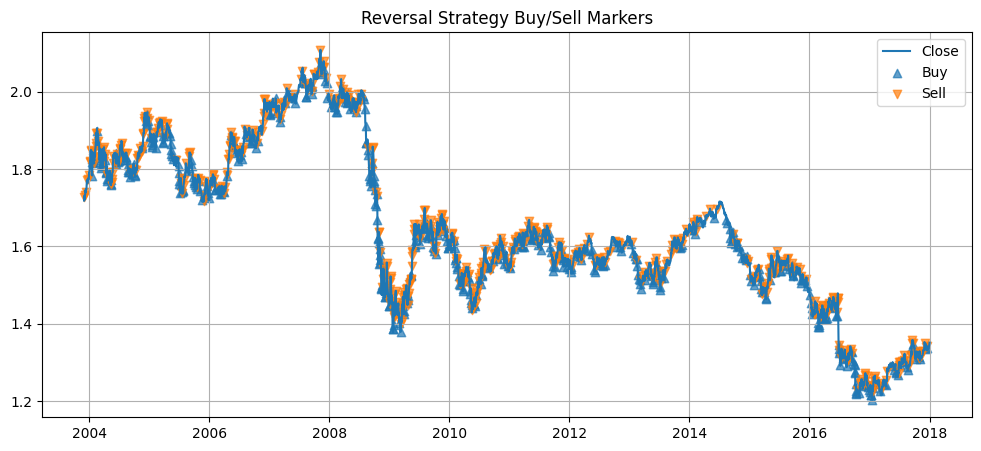

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(reversal_result.index, reversal_result['Close'], label='Close')

buy_signals = reversal_result[reversal_result['Signal_REV'] == 1]
sell_signals = reversal_result[reversal_result['Signal_REV'] == -1]

plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', label='Buy', alpha=0.7)
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', label='Sell', alpha=0.7)

plt.title('Reversal Strategy Buy/Sell Markers')
plt.legend()
plt.grid(True)
plt.show()

📊 Section 6 – Local Extrema & Trend

🔹 Cell 20 – Detect Local Extrema

Section 6 – Tasks: Run argrelextrema and overlay peaks/troughs

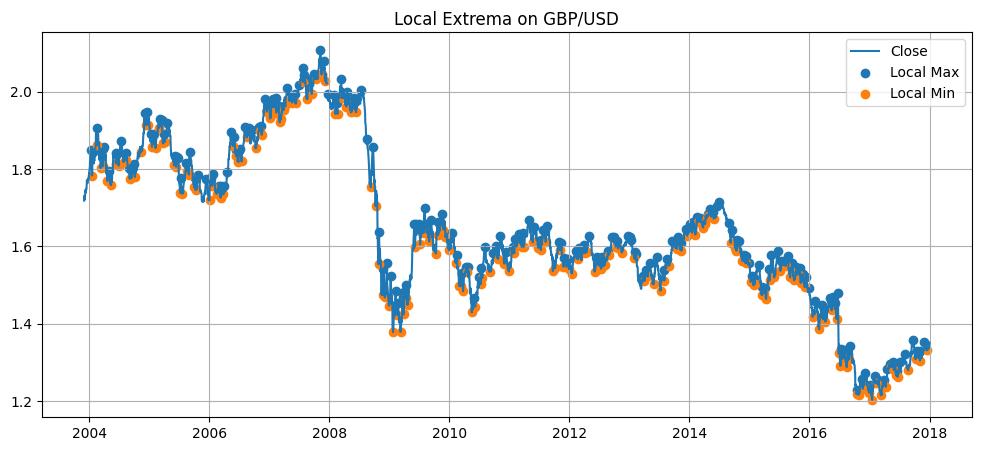

In [25]:
# Cell 20

from scipy.signal import argrelextrema

def detect_extrema(df, order=5):
    data = df.copy()
    prices = data['Close'].values
    local_max_idx = argrelextrema(prices, np.greater, order=order)[0]
    local_min_idx = argrelextrema(prices, np.less, order=order)[0]
    
    data['Local_Max'] = np.nan
    data['Local_Min'] = np.nan
    
    data.iloc[local_max_idx, data.columns.get_loc('Local_Max')] = data['Close'].iloc[local_max_idx]
    data.iloc[local_min_idx, data.columns.get_loc('Local_Min')] = data['Close'].iloc[local_min_idx]
    return data

extrema_data = detect_extrema(data, order=5)

plt.figure(figsize=(12, 5))
plt.plot(extrema_data.index, extrema_data['Close'], label='Close')
plt.scatter(extrema_data.index, extrema_data['Local_Max'], marker='o', label='Local Max')
plt.scatter(extrema_data.index, extrema_data['Local_Min'], marker='o', label='Local Min')
plt.title('Local Extrema on GBP/USD')
plt.legend()
plt.grid(True)
plt.show()

⚖️ Section 7 – Trade Simulation & Reporting

🔹 Cell 21 – Generic Trade Simulation

Section 7 – Tasks: simulate_trades, generate performance report

In [26]:
def simulate_trades(df, signal_col='Signal'):
    data = df.copy()
    data['Return'] = data['Close'].pct_change()
    data['Strategy_Return'] = data[signal_col].shift(1) * data['Return']
    data['Equity'] = (1 + data['Strategy_Return']).cumprod()
    return data

🔹 Cell 22 – Simulate & Report: Optimized SMA

Section 7 – Compare with optimized MA

In [27]:
sim_sma = simulate_trades(best_equity_curve, signal_col='Signal_SMA')
report_sma = performance_report(sim_sma, equity_col='Equity', strat_ret_col='Strategy_Return')
report_sma

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\904189121.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data['Close'].pct_change()


{'Final Balance (start=1)': np.float64(0.9222413927824945),
 'Total Return (%)': np.float64(-7.775860721750549),
 'Win Rate (%)': np.float64(49.189337730145645),
 'Max Drawdown (%)': np.float64(-27.341564831472066),
 'Average P&L per Period (%)': np.float64(-0.00038544151163041657)}

🔹 Cell 23 – Simulate & Report: Reversal Strategy

Section 7 – Compare with reversal signals

In [28]:
sim_rev = simulate_trades(reversal_result, signal_col='Signal_REV')
report_rev = performance_report(sim_rev, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
report_rev

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\904189121.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data['Close'].pct_change()


{'Final Balance (start=1)': np.float64(1.2630938711372135),
 'Total Return (%)': np.float64(26.30938711372135),
 'Win Rate (%)': np.float64(51.57807308970099),
 'Max Drawdown (%)': np.float64(-14.220692418078883),
 'Average P&L per Period (%)': np.float64(0.007150735037407946)}

🧠 Section 8 – Mini Projects (EMA, RSI, Bollinger, Hybrid, Optimization)

🔹 Cell 24 – EMA Crossover Strategy

Section 8 – EMA Crossover

In [29]:
def ema_crossover_strategy(df, short_span=10, long_span=30):
    data = df.copy()
    data['EMA_Short'] = data['Close'].ewm(span=short_span, adjust=False).mean()
    data['EMA_Long'] = data['Close'].ewm(span=long_span, adjust=False).mean()
    
    data['Signal_EMA'] = 0
    data['Signal_EMA'] = np.where(data['EMA_Short'] > data['EMA_Long'], 1, -1)
    data['Signal_EMA'] = data['Signal_EMA'].shift(1)
    
    data = calculate_returns(data, signal_col='Signal_EMA')
    return data

ema_result = ema_crossover_strategy(data)
performance_report(ema_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


{'Final Balance (start=1)': np.float64(0.7495774469023064),
 'Total Return (%)': np.float64(-25.042255309769356),
 'Win Rate (%)': np.float64(48.749656499038196),
 'Max Drawdown (%)': np.float64(-39.584307606835665),
 'Average P&L per Period (%)': np.float64(-0.006019585374509611)}

🔹 Cell 25 – RSI + RSI Strategy

Section 8 – RSI Strategy

In [32]:
# Cell 25

def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    rsi_val = 100 - (100 / (1 + rs))
    return rsi_val

def rsi_strategy(df, period=14, lower=30, upper=70):
    data = df.copy()
    data['RSI'] = rsi(data['Close'], period=period)
    data['Signal_RSI'] = 0
    data['Signal_RSI'] = np.where(data['RSI'] < lower, 1, data['Signal_RSI'])
    data['Signal_RSI'] = np.where(data['RSI'] > upper, -1, data['Signal_RSI'])
    data['Signal_RSI'] = data['Signal_RSI'].shift(1)
    data = calculate_returns(data, signal_col='Signal_RSI')
    return data

rsi_result = rsi_strategy(data)
performance_report(rsi_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


{'Final Balance (start=1)': np.float64(1.1486818550281441),
 'Total Return (%)': np.float64(14.868185502814413),
 'Win Rate (%)': np.float64(52.863436123348016),
 'Max Drawdown (%)': np.float64(-12.885176474213333),
 'Average P&L per Period (%)': np.float64(0.00422974593755789)}

🔹 Cell 26 – Bollinger Bands Strategy

Section 8 – Bollinger Bands

In [33]:
# Cell 26

def bollinger_bands_strategy(df, window=20, num_std=2):
    data = df.copy()
    rolling_mean = data['Close'].rolling(window).mean()
    rolling_std = data['Close'].rolling(window).std()
    
    data['BB_Mid'] = rolling_mean
    data['BB_Upper'] = rolling_mean + num_std * rolling_std
    data['BB_Lower'] = rolling_mean - num_std * rolling_std
    
    data['Signal_BB'] = 0
    data['Signal_BB'] = np.where(data['Close'] < data['BB_Lower'], 1, data['Signal_BB'])
    data['Signal_BB'] = np.where(data['Close'] > data['BB_Upper'], -1, data['Signal_BB'])
    data['Signal_BB'] = data['Signal_BB'].shift(1)
    
    data = calculate_returns(data, signal_col='Signal_BB')
    return data

bb_result = bollinger_bands_strategy(data)
performance_report(bb_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')


C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


{'Final Balance (start=1)': np.float64(0.8743941400077405),
 'Total Return (%)': np.float64(-12.560585999225948),
 'Win Rate (%)': np.float64(48.433048433048434),
 'Max Drawdown (%)': np.float64(-14.806385942915334),
 'Average P&L per Period (%)': np.float64(-0.0034686964552371087)}

🔹 Cell 27 – Hybrid Strategy (SMA + Reversal Confirmation)

Section 8 – Hybrid Strategy

In [34]:
# Cell 27

def hybrid_strategy(df, short_window=10, long_window=30, pip_threshold=0.005):
    sma = sma_crossover_strategy(df, short_window, long_window)
    rev = identify_reverse_patterns(df, pip_threshold)
    
    data = df.copy()
    data['Signal_SMA'] = sma['Signal_SMA']
    data['Signal_REV'] = rev['Signal_REV']
    
    data['Signal_HYB'] = 0
    mask = data['Signal_SMA'] == data['Signal_REV']
    data.loc[mask, 'Signal_HYB'] = data.loc[mask, 'Signal_SMA']
    
    data['Signal_HYB'] = data['Signal_HYB'].shift(1)
    
    data = calculate_returns(data, signal_col='Signal_HYB')
    return data

hyb_result = hybrid_strategy(data)
performance_report(hyb_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_31372\991340881.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data['Close'].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fi

{'Final Balance (start=1)': np.float64(0.8517078149782251),
 'Total Return (%)': np.float64(-14.829218502177488),
 'Win Rate (%)': np.float64(48.91846921797005),
 'Max Drawdown (%)': np.float64(-21.862133088488044),
 'Average P&L per Period (%)': np.float64(-0.0040247741495724855)}

🔹 Cell 28 – Optimization Challenge: RSI Thresholds

Section 8 – Optimization Challenge

In [35]:
# Cell 28

def optimize_rsi_thresholds(df, period=14, lower_list=[25, 30, 35], upper_list=[65, 70, 75]):
    best_perf = -np.inf
    best_params = None
    best_df = None
    for lo in lower_list:
        for up in upper_list:
            if lo >= up:
                continue
            res = rsi_strategy(df, period=period, lower=lo, upper=up)
            final_equity = res['Equity_Curve'].iloc[-1]
            print(f"RSI lower={lo}, upper={up}, final equity={final_equity:.4f}")
            if final_equity > best_perf:
                best_perf = final_equity
                best_params = (lo, up)
                best_df = res
    return best_params, best_df

best_rsi_params, best_rsi_df = optimize_rsi_thresholds(data)
best_rsi_params, performance_report(best_rsi_df, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')

RSI lower=25, upper=65, final equity=0.9636
RSI lower=25, upper=70, final equity=1.0440
RSI lower=25, upper=75, final equity=1.0034
RSI lower=30, upper=65, final equity=1.0602
RSI lower=30, upper=70, final equity=1.1487
RSI lower=30, upper=75, final equity=1.1040
RSI lower=35, upper=65, final equity=0.9977
RSI lower=35, upper=70, final equity=1.0810
RSI lower=35, upper=75, final equity=1.0390


C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()
C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not

((30, 70),
 {'Final Balance (start=1)': np.float64(1.1486818550281441),
  'Total Return (%)': np.float64(14.868185502814413),
  'Win Rate (%)': np.float64(52.863436123348016),
  'Max Drawdown (%)': np.float64(-12.885176474213333),
  'Average P&L per Period (%)': np.float64(0.00422974593755789)})

🧾 Section 9 – Reflection & Analysis

🔹 Cell 29 – Reflection (Markdown)

Section 9 – Discussion questions

Add a Markdown cell and write your own reflection using hints like:

Trend-following vs mean-reversion in different markets

Problems with static parameters

How ML could classify regimes and switch strategies

🧩 Section 10 – Multi-Strategy Comparison

🔹 Cell 30 – Mean Reversion Strategy

Section 10 – Mean Reversion

In [36]:
# Cell 30

def mean_reversion_strategy(df, window=20, threshold=0.01):
    data = df.copy()
    data['MA'] = data['Close'].rolling(window).mean()
    data['Dev'] = (data['Close'] - data['MA']) / data['MA']
    
    data['Signal_MR'] = 0
    data['Signal_MR'] = np.where(data['Dev'] <= -threshold, 1, data['Signal_MR'])
    data['Signal_MR'] = np.where(data['Dev'] >= threshold, -1, data['Signal_MR'])
    data['Signal_MR'] = data['Signal_MR'].shift(1)
    
    data = calculate_returns(data, signal_col='Signal_MR')
    return data

mr_result = mean_reversion_strategy(data)
performance_report(mr_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


{'Final Balance (start=1)': np.float64(1.035289221021551),
 'Total Return (%)': np.float64(3.5289221021550965),
 'Win Rate (%)': np.float64(52.03197868087941),
 'Max Drawdown (%)': np.float64(-23.412304599735556),
 'Average P&L per Period (%)': np.float64(0.0018790667738176738)}

🔹 Cell 31 – Momentum Breakout Strategy

Section 10 – Momentum Breakout

In [38]:
# Cell 31

def momentum_breakout_strategy(df, window=20):
    data = df.copy()
    data['Roll_Max'] = data['Close'].rolling(window).max()
    data['Roll_Min'] = data['Close'].rolling(window).min()
    
    data['Signal_MB'] = 0
    data['Signal_MB'] = np.where(data['Close'] > data['Roll_Max'].shift(1), 1, data['Signal_MB'])
    data['Signal_MB'] = np.where(data['Close'] < data['Roll_Min'].shift(1), -1, data['Signal_MB'])
    data['Signal_MB'] = data['Signal_MB'].shift(1)
    
    data = calculate_returns(data, signal_col='Signal_MB')
    return data

mb_result = momentum_breakout_strategy(data)
performance_report(mb_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')

C:\Users\hp\AppData\Local\Temp\ipykernel_31372\2590612797.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Return'] = data[price_col].pct_change()


{'Final Balance (start=1)': np.float64(0.8398241835134518),
 'Total Return (%)': np.float64(-16.017581648654822),
 'Win Rate (%)': np.float64(48.28431372549019),
 'Max Drawdown (%)': np.float64(-30.082705344060567),
 'Average P&L per Period (%)': np.float64(-0.004278984104877715)}

🔹 Cell 32 – Performance Comparison Table

Section 10 & 11 – side-by-side table of strategies

In [39]:
#Cell 32

from collections import OrderedDict

results_dict = OrderedDict()

results_dict['SMA_Optimized'] = performance_report(best_equity_curve, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
results_dict['EMA'] = performance_report(ema_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
results_dict['RSI'] = performance_report(rsi_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
results_dict['Bollinger'] = performance_report(bb_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
results_dict['MeanReversion'] = performance_report(mr_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
results_dict['MomentumBreakout'] = performance_report(mb_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
results_dict['Hybrid'] = performance_report(hyb_result, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')
results_dict['RSI_Optimized'] = performance_report(best_rsi_df, equity_col='Equity_Curve', strat_ret_col='Strategy_Return')

comparison_df = pd.DataFrame(results_dict).T
comparison_df

,Final Balance (start=1),Total Return (%),Win Rate (%),Max Drawdown (%),Average P&L per Period (%)
SMA_Optimized,0.922241,-7.775861,49.189338,-27.341565,-0.000385
EMA,0.749577,-25.042255,48.749656,-39.584308,-0.006020
RSI,1.148682,14.868186,52.863436,-12.885176,0.004230
Bollinger,0.874394,-12.560586,48.433048,-14.806386,-0.003469
MeanReversion,1.035289,3.528922,52.031979,-23.412305,0.001879
MomentumBreakout,0.839824,-16.017582,48.284314,-30.082705,-0.004279
Hybrid,0.851708,-14.829219,48.918469,-21.862133,-0.004025
RSI_Optimized,1.148682,14.868186,52.863436,-12.885176,0.004230


🔹 Cell 33 – Plot Multi-Strategy Equity Curves

Section 10 – side-by-side comparison plot

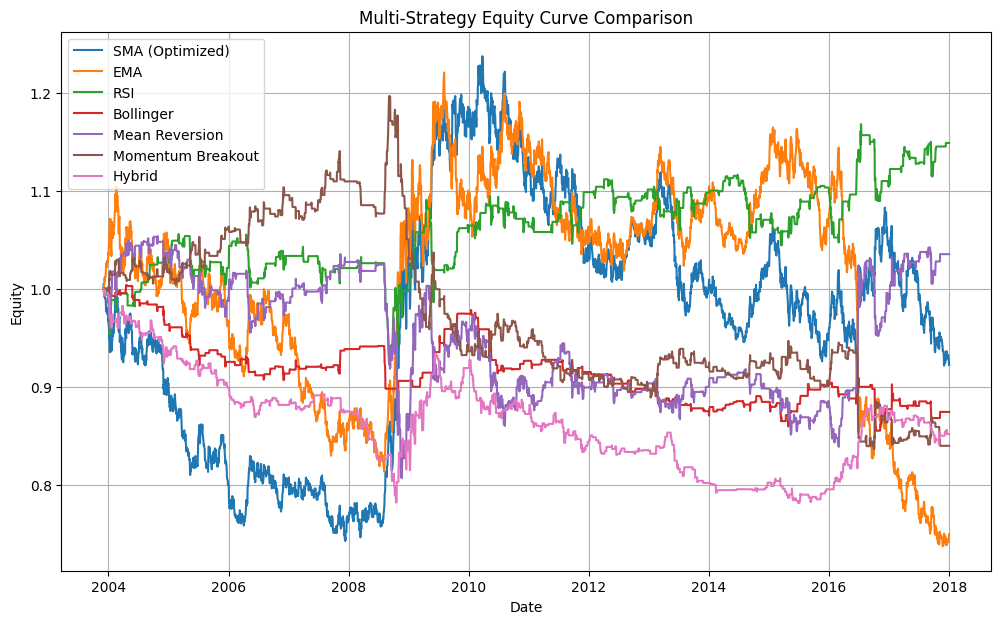

In [40]:
plt.figure(figsize=(12, 7))
plt.plot(best_equity_curve.index, best_equity_curve['Equity_Curve'], label='SMA (Optimized)')
plt.plot(ema_result.index, ema_result['Equity_Curve'], label='EMA')
plt.plot(rsi_result.index, rsi_result['Equity_Curve'], label='RSI')
plt.plot(bb_result.index, bb_result['Equity_Curve'], label='Bollinger')
plt.plot(mr_result.index, mr_result['Equity_Curve'], label='Mean Reversion')
plt.plot(mb_result.index, mb_result['Equity_Curve'], label='Momentum Breakout')
plt.plot(hyb_result.index, hyb_result['Equity_Curve'], label='Hybrid')

plt.title('Multi-Strategy Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(True)
plt.show()

🔹 Cell 34 – Final Summary (Markdown)

Section 11 – Strategy Performance Summary

In Markdown, use comparison_df values to comment on:

Which strategy had highest final balance / return

Which had lowest drawdown

Which had best win rate

Trade-off between risk & return

Which one you’d choose and why